<a href="https://colab.research.google.com/github/Rogerio-mack/IA_2026S1/blob/main/TensorFlow_Penguins_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TensorFlow: Penguins Example**

In [ ]:
import seaborn as sns

# Load the penguins dataset
df = sns.load_dataset("penguins")

display(df.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Variáveis de entrada e saída

df = df.dropna()
X = df.drop(columns=["species"])
y = df["species"]

# Identificar colunas categóricas e numéricas
cat_cols = X.select_dtypes(include=["object"]).columns
num_cols = X.select_dtypes(include=["float64", "int64"]).columns

# 2) One-hot nas variáveis categóricas
ohe = OneHotEncoder(sparse_output=False)
X_cat = ohe.fit_transform(X[cat_cols])

# 3) Normalização numérica
scaler = StandardScaler()
X_num = scaler.fit_transform(X[num_cols])

# 4) Concatenar
X_processed = np.hstack([X_num, X_cat])

# 5) Converter `y` para labels numéricos (0,1,2)
y_int = y.astype("category").cat.codes  # 0, 1, 2

# 6) Treino/Teste
X_train, X_test, y_train_int, y_test_int = train_test_split(
    X_processed, y_int, test_size=0.2, random_state=42
)


## Modelo 1, `sparse_categorical_crossentropy`, `y_train=[1,2,3,...]`

In [ ]:
pd.concat([pd.DataFrame(X_train).reset_index(drop=True), pd.DataFrame(y_train_int).reset_index(drop=True)], axis=1).head()

,0,1,2,3,4,5,6,7,8,0
0,-0.566399,-1.762145,0.931283,0.550920,1.0,0.0,0.0,1.0,0.0,2
1,-1.225685,0.323014,-0.712196,-1.065984,0.0,1.0,0.0,1.0,0.0,0
2,1.100130,-0.643279,1.645839,1.421560,1.0,0.0,0.0,0.0,1.0,2
3,-1.482074,1.035020,-0.855107,-0.506286,1.0,0.0,0.0,1.0,0.0,0
4,-0.639653,0.882447,-1.498207,-0.319720,1.0,0.0,0.0,0.0,1.0,0


In [ ]:
# Modelo 1: y como inteiros
model1 = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train, y_train_int,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=0
)

loss1, acc1 = model1.evaluate(X_test, y_test_int, verbose=0)
print(f"Modelo 1 - Acurácia (classes inteiras): {acc1:.4f}")


Modelo 1 - Acurácia (classes inteiras): 1.0000


In [ ]:
model1.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 971 (3.80 KB)

 Trainable params: 323 (1.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 648 (2.54 KB)

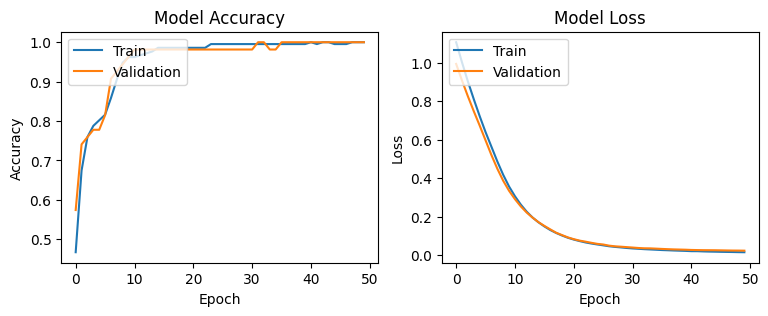

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):

  # Plot training & validation accuracy values
  plt.figure(figsize=(9,3))
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.title('Model Accuracy')
  plt.ylabel('Accuracy')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')

  # Plot training & validation loss values
  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.title('Model Loss')
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.legend(['Train', 'Validation'], loc='upper left')

  plt.show()

plot_history(history1)

In [ ]:
# Get predictions from model1
y_pred_int_model1 = model1.predict(X_test).argmax(axis=1)

# Display the first few predictions (integers)
print("Predicted class labels from model1 (integers):")
print(y_pred_int_model1[:5])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Predicted class labels from model1 (integers):
[0 2 0 1 0]


In [ ]:
from sklearn.metrics import classification_report

# Get predictions from model1
y_pred_int = model1.predict(X_test).argmax(axis=1)

# Generate and print the classification report
print(classification_report(y_test_int, y_pred_int))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



## Modelo 2, `categorical_crossentropy`, `y_train=[[1,0,0,...],[0,0,1,...],...]`

In [ ]:
# Converter y para one-hot
y_train_oh = tf.keras.utils.to_categorical(y_train_int, num_classes=3)
y_test_oh  = tf.keras.utils.to_categorical(y_test_int, num_classes=3)

# Modelo 2: y como one-hot
model2 = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train, y_train_oh,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test_oh, verbose=0)
print(f"Modelo 2 - Acurácia (one-hot): {acc2:.4f}")


Modelo 2 - Acurácia (one-hot): 1.0000


In [ ]:
model2.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 971 (3.80 KB)

 Trainable params: 323 (1.26 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 648 (2.54 KB)

In [ ]:
# Get predictions from model2
y_pred_oh = model2.predict(X_test)

# Display the first few predictions (one-hot encoded)
print("Predictions from model2 (one-hot encoded):")
print(y_pred_oh[:5])

# To get the predicted class labels (integers)
y_pred_int_model2 = y_pred_oh.argmax(axis=1)

print("\nPredicted class labels (integers):")
print(y_pred_int_model2[:5])

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Predictions from model2 (one-hot encoded):
[[8.46226156e-01 1.53638616e-01 1.35196489e-04]
 [6.00503478e-03 1.17543316e-07 9.93994832e-01]
 [9.98818219e-01 7.54938577e-04 4.26904560e-04]
 [6.90592919e-03 9.93090987e-01 3.05481285e-06]
 [9.99558151e-01 1.07554326e-04 3.34239419e-04]]

Predicted class labels (integers):
[0 2 0 1 0]


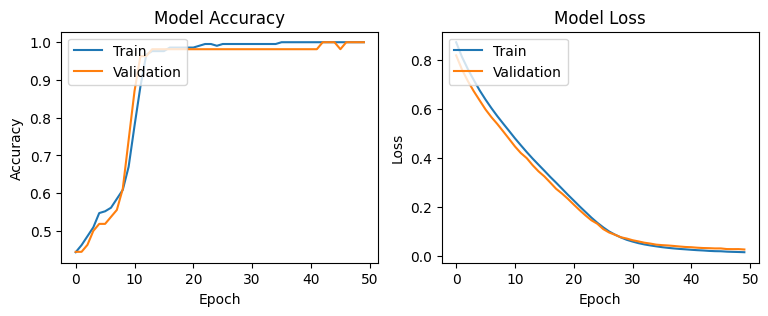

In [ ]:
plot_history(history2)

In [ ]:
from sklearn.metrics import classification_report

# Get predictions from model1
y_pred_int = model1.predict(X_test).argmax(axis=1)

# Generate and print the classification report
print(classification_report(y_test_int, y_pred_int))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        31
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        23

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67

